# Categorical features

`effector` distinguishes three feature types (see `docs/guides/method_semantics.md` for the exact formulas):

| type | meaning | example |
|---|---|---|
| `continuous` | any real value is valid | temperature |
| `ordinal` | discrete levels with a natural order | counts, ratings |
| `nominal` | discrete levels without an order | color, weekday |

Types arrive through the `schema=` argument, or are inferred: pandas dtypes decide on DataFrames (`category` → nominal, ordered `category` → ordinal, low-cardinality int → ordinal), and integer-valued low-cardinality columns of a numpy array are read as ordinal (with a warning — declare types to silence it).

The capability matrix:

| method | continuous | ordinal | nominal |
|---|---|---|---|
| PDP / ICE | ✓ | ✓ levels, bars | ✓ levels, bars |
| DerPDP | ✓ | ✓ ICE differences, transition bars | ✓ transition bars + all-pairs scalars |
| ALE | ✓ | ✓ exact | ✓ + order caveat |
| RHALE | ✓ | ✓ + level grouping | ✓ as ALE (no grouping) |
| ShapDP | ✓ | ✓ per level | ✓ per level |

In [1]:
import numpy as np
import pandas as pd
import effector
from effector import models

np.random.seed(21)

## A model with a categorical feature of interest

We use the closed-form model $f(x) = a_{x_0} + b_{x_0}\, x_1 \, \mathbb{1}_{x_2>0}$ with $x_0 \in \{0, 1, 2\}$, $a = [0, 1, 3]$, $b = [1, -1, 0]$: the effect of $x_0$ is a per-level constant, and its *heterogeneity* comes from the interaction with $x_1, x_2$.

In [2]:
model = models.ConditionalCategorical()

N = 1_000
rng = np.random.default_rng(21)
data = np.stack([
    rng.choice([0.0, 1.0, 2.0], N, p=[0.5, 0.3, 0.2]),
    rng.uniform(-1, 1, N),
    rng.uniform(-1, 1, N),
], axis=1)

schema = {"feature_names": ["level", "x1", "x2"], "feature_types": ["ordinal", "continuous", "continuous"]}

## PDP: bars at the levels, ICE as jittered dots

For a discrete feature the model is evaluated **only at the observed levels** — never at fake in-between values. Verbs take the feature by index or by name — `pdp.plot(0)` and `pdp.plot("level")` are the same call; we use the name below.


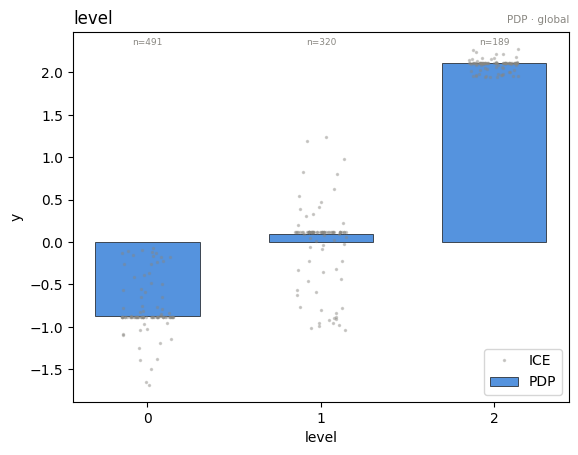

In [3]:
pdp = effector.PDP(data, model.predict, schema=schema)
pdp.plot("level", heterogeneity="ice", centering=True)

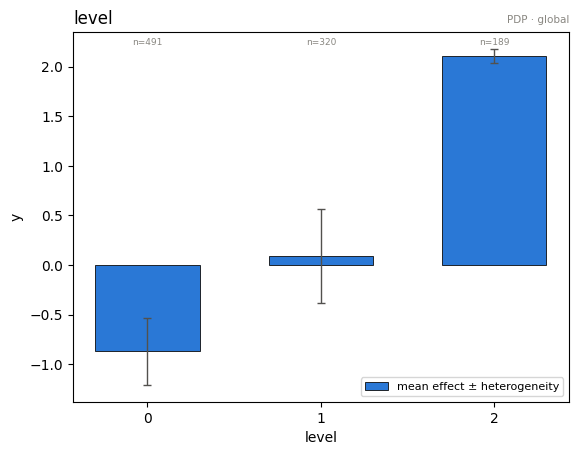

In [4]:
pdp.plot("level", heterogeneity="std", centering=True)

`eval` follows the same rule — asking for a non-level value is an error:

In [5]:
print(pdp.eval("level", np.array([0.0, 1.0, 2.0]), centering="zero_start"))
try:
    pdp.eval("level", np.array([0.5]))
except ValueError as e:
    print("ValueError:", e)

[0.         0.96102959 2.9805148 ]
ValueError: level is categorical and can only be evaluated at its observed levels [0.0, 1.0, 2.0]; got invalid value(s) [0.5]


## ALE: adjacent-level differences, accumulated

Each bar is the accumulated effect at a level; the whisker is the standard deviation of the *step into* that level. For an ordinal feature this is exact — the model is only queried at real levels.

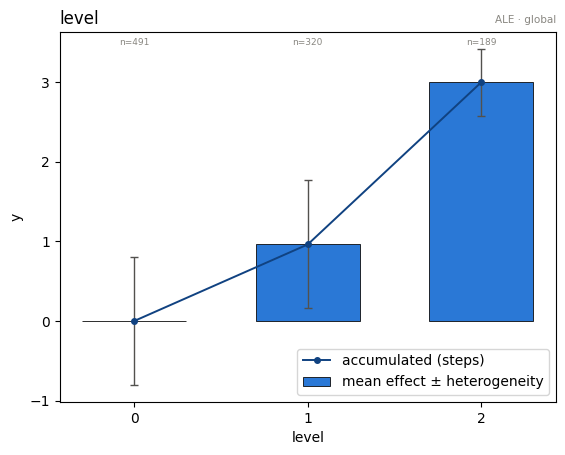

In [6]:
ale = effector.ALE(data, model.predict, schema=schema)
ale.plot("level", centering="zero_start")

## RHALE: adaptive level grouping

On ordinal features RHALE treats the adjacent-level differences as a discrete derivative and lets Greedy/DP binning merge neighboring transitions with similar effect — useful for high-cardinality ordinal features.

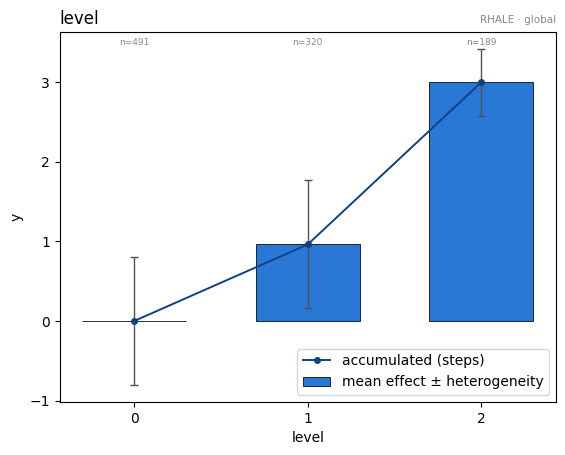

In [7]:
rhale = effector.RHALE(data, model.predict, model.jacobian, schema=schema)
rhale.fit(0, binning_method="greedy", centering="zero_start")
rhale.plot("level", centering="zero_start")

## DerPDP differentiates discretely

On a discrete axis the derivative becomes the finite difference: for every instance, the change in prediction when the level switches to the next one. The jacobian is never used there — the bars below are per-transition means (± std) of the plain ICE differences, labeled `v→w`.


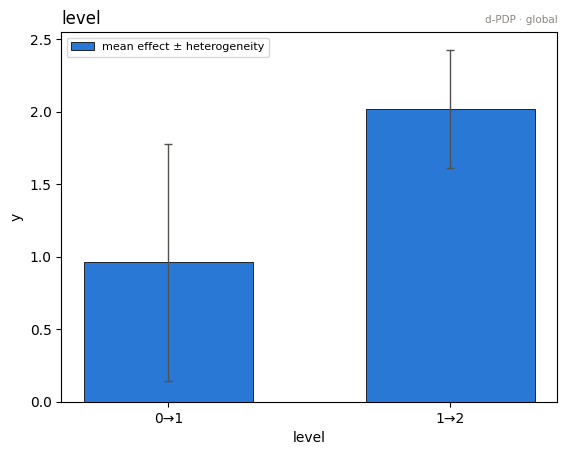

heter_score: 0.58
importance : 0.891


In [8]:
derpdp = effector.DerPDP(data, model.predict, model.jacobian, schema=schema)
derpdp.plot("level", heterogeneity="std")
print("heter_score:", round(derpdp.heter_score(0), 3))
print("importance :", round(derpdp.importance(0), 3))

## Importance and one-click explanation

Every global effect exposes `importances()` — the per-feature dispersion of the *mean* effect (the μ-twin of heterogeneity), a scalar summary of how much each feature moves the prediction. `effector.explain(...)` wraps the whole tour into a serializable `Report` with a self-contained HTML view.

In [9]:
# per-feature importance = dispersion of the mean effect (the mu-twin of heterogeneity)
print("importances:", np.round(pdp.importances(), 3))

# one-click auto-explanation -> Report (serializable; self-contained HTML)
report = effector.explain(data, model.predict, method="pdp", schema=schema, nof_instances="all")
report.show()

importances: [1.103 0.039 0.007]
[effector] global effects reproduce 90.5% of the model's variance; with subregions, 98.4%

PDP report — target: y
data: 1,000 instances × 3 features (1 ordinal · 2 continuous) — target y
model output: mean 0.875, std 1.17, range [-0.993, 3]
explained variance: global effects (GAM) 90.5%
  + split x1 (on level, x2) → 98.4% (+7.9 pts, heter 0.370→0.076)
  rejected: level (on x1, x2) — -4.8 pts, redundant (variance already explained)
------------------------------------------------------------
feature                   importance     heter  #regions
------------------------------------------------------------
level                         1.1028    0.3607         1
x1                            0.2291    0.0757         5
the plotted features carry 99% of the total importance mass


Feature 1 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
x1 🔹 [id: 0 | heter: 0.37 | inst: 1000 | w: 1.00]
    x2 < 0.00 🔹 [id: 1 | heter: 0.00 | inst: 49

## Regional effects on a categorical feature

*For which subgroups is the per-level effect stable?* We use $f(x) = a_{x_0} + b_{x_0}\,\mathbb{1}_{x_2>0}$: the level effect is unstable globally, but perfectly stable once you condition on the $x_2$ gate.

In [10]:
A, B = models.ConditionalCategorical.A, models.ConditionalCategorical.B

def gated_model(x):
    codes = x[:, 0].astype(int)
    return A[codes] + B[codes] * (x[:, 2] > 0)

pdp_reg = effector.PDP(data, gated_model, schema=schema, nof_instances="all")
pdp_reg.fit(0, centering=True)
finder = effector.space_partitioning.Best(max_depth=1)
partitions = {0: pdp_reg.find_regions(0, finder=finder)}
partitions[0].show()



Feature 0 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
level 🔹 [id: 0 | heter: 0.44 | inst: 1000 | w: 1.00]
    x2 < 0.00 🔹 [id: 1 | heter: 0.00 | inst: 498 | w: 0.50]
    x2 ≥ 0.00 🔹 [id: 2 | heter: 0.00 | inst: 502 | w: 0.50]
--------------------------------------------------
Feature 0 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 0.44
    Level 1🔹heter: 0.00 | 🔻0.44 (100.00%)




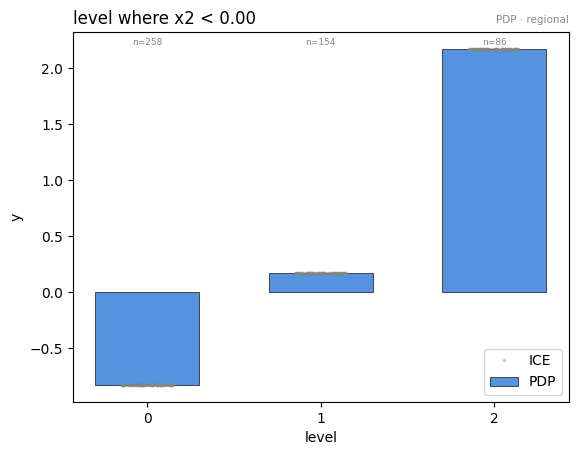

In [11]:
partitions[0].plot(1, heterogeneity="ice", centering=True)

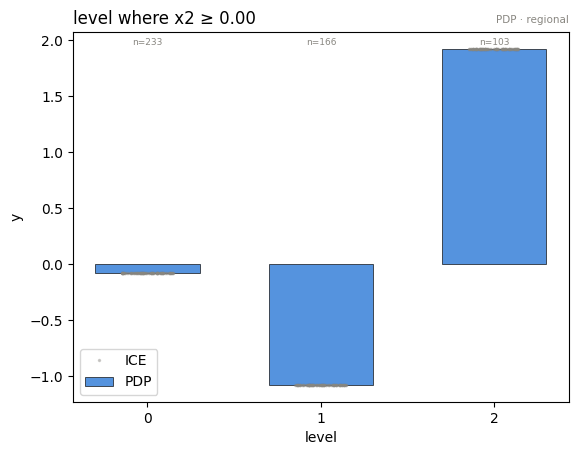

In [12]:
partitions[0].plot(2, heterogeneity="ice", centering=True)

## Nominal features from a pandas DataFrame

effector is numpy-only, so a DataFrame is converted at the door with `effector.from_dataframe(df)`, which returns `(X, schema)`: `X` is the encoded `(N, D)` numpy matrix and `schema` carries the feature types and the category labels. Your model stays a plain numpy→numpy callable (it receives the encoded codes). Plots translate the codes back to the category labels via the schema.

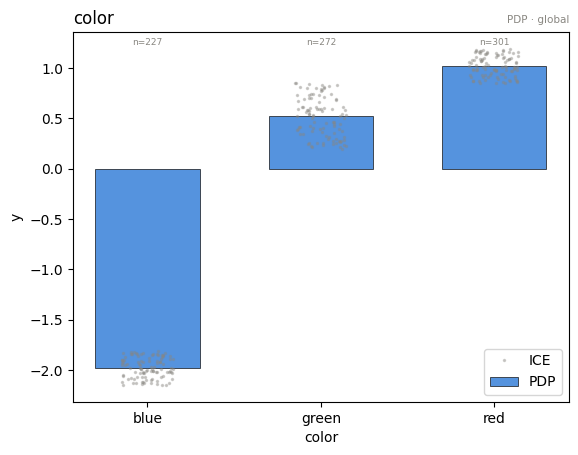

In [13]:
N2 = 800
color = rng.choice(["red", "green", "blue"], N2, p=[0.4, 0.35, 0.25])
df = pd.DataFrame({
    "color": pd.Categorical(color),
    "x1": rng.uniform(-1, 1, N2),
})

# effector is numpy-only: convert the DataFrame to (X, schema) at the door.
X, schema_nominal = effector.from_dataframe(df)
levels = schema_nominal.category_names[0]  # e.g. ['blue', 'green', 'red']

# the model is numpy->numpy; it receives the encoded codes in column 0.
color_effect = {"red": 2.0, "green": 1.5, "blue": -1.0}
effect_by_code = np.array([color_effect[name] for name in levels])
green_code = levels.index("green")

def np_model(x):
    codes = x[:, 0].astype(int)
    return effect_by_code[codes] + 0.5 * x[:, 1] * (codes == green_code)

pdp_nominal = effector.PDP(X, np_model, schema=schema_nominal)
pdp_nominal.plot(0, heterogeneity="ice", centering=True)

### ALE on a nominal feature: the order caveat

ALE accumulates along an order that nominal features do not have. By default effector uses the ascending encoded order and the curve's *shape* depends on it — the meaningful quantities are the adjacent-level differences. You can declare the order (`order=[...]`) or induce it from the other features (`order="similarity"`, Kolmogorov–Smirnov seriation):

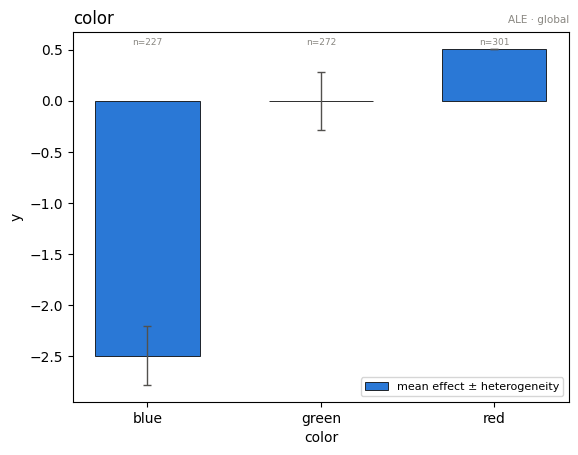

In [14]:
ale_nominal = effector.ALE(X, np_model, schema=schema_nominal)
ale_nominal.fit(0, centering="zero_start", order="similarity")
ale_nominal.plot(0, centering="zero_start")

## Takeaways

- Declare `feature_types` in the `schema` whenever you know them — inference is a fallback, not an oracle.
- PDP/ShapDP treat ordinal and nominal identically (order-free math); ALE needs an order; RHALE groups adjacent levels only when the order is *real* (ordinal) and falls back to plain ALE on nominal.
- DerPDP differentiates discretely: per-transition ICE differences, never the jacobian.
- `heter_score`/`importance` are std-type scalars in output units (the units contract) — comparable across feature types and, in magnitude, across methods; for nominal features they are order-free (all level pairs).
- Regional effects answer stability questions per level — heterogeneity is frequency-weighted over the levels.
- The exact formulas per method and feature type live in `docs/guides/method_semantics.md`.

## Cross-method sanity check

The one-liner `effector.explain` with every engine this notebook's model
supports. Everything must run end to end; the closing table puts the reads
side by side. Where methods disagree — ranking, accepted splits, R² — that is
a property of the data/model worth a closer look, not an error.


In [15]:
from pathlib import Path
_out = Path("reports") / "08_categorical_features"
_out.mkdir(parents=True, exist_ok=True)

# === cross-method sweep: effector.explain on every applicable engine ======
sweep_reports = {}
for _m in ["pdp", "derpdp", "ale", "rhale", "shapdp"]:
    _kw = {"nof_instances": 300} if _m == "shapdp" else {}
    print(f"--- {_m} " + "-" * 50)
    sweep_reports[_m] = effector.explain(
        data, model.predict, model.jacobian, method=_m, schema=schema, **_kw
    )
    sweep_reports[_m].to_html(_out / f"report_{_m}.html")

print()
print(f"{'method':<8} {'ranking (plotted)':<44} {'GAM R2':>8} {'final R2':>9}  splits")
for _m, _r in sweep_reports.items():
    _rank = " > ".join(fr.name for fr in _r.features)
    _ev = _r.explained_variance
    if _ev:
        _sp = "; ".join(f"{s['name']} on {s['on']}" for s in _ev["stages"]) or "none"
        print(f"{_m:<8} {_rank:<44} {_ev['gam_r2']:>7.1%} {_ev['regional_r2']:>8.1%}  {_sp}")
    else:
        print(f"{_m:<8} {_rank:<44} {'-':>7} {'-':>8}  (derivative scale: no variance ledger)")

print(f"\nreports stored in {_out}/")


--- pdp --------------------------------------------------
[effector] global effects reproduce 90.5% of the model's variance; with subregions, 98.4%


/home/givasile/github/packages/effector/effector/report.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


--- derpdp --------------------------------------------------


/home/givasile/github/packages/effector/effector/report.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


--- ale --------------------------------------------------


...

/home/givasile/github/packages/effector/effector/report.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


--- shapdp --------------------------------------------------


[effector] global effects reproduce 90.4% of the model's variance; with subregions, 98.2%


/home/givasile/github/packages/effector/effector/report.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()



method   ranking (plotted)                              GAM R2  final R2  splits
pdp      level > x1                                     90.5%    98.4%  x1 on level, x2
derpdp   level                                              -        -  (derivative scale: no variance ledger)
ale      level                                          90.3%    97.4%  level on x1, x2
rhale    level > x1                                     90.5%    98.4%  x1 on level, x2
shapdp   level > x1                                     90.4%    98.2%  x1 on level, x2; level on x1, x2

reports stored in reports/08_categorical_features/
